<a href="https://colab.research.google.com/github/kkbin505/MEng_classify_fashion_MNIST/blob/CNN---Angela/CNN_Angela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!git clone https://github.com/kkbin505/MEng_classify_fashion_MNIST.git

Cloning into 'MEng_classify_fashion_MNIST'...
remote: Enumerating objects: 2949, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 2949 (delta 15), reused 139 (delta 2), pack-reused 2778 (from 2)
Receiving objects: 100% (2949/2949), 136.77 MiB | 20.94 MiB/s, done.
Resolving deltas: 100% (480/480), done.


In [8]:
import os
os.chdir("/content/MEng_classify_fashion_MNIST")
!pwd

/content/MEng_classify_fashion_MNIST


In [9]:
!pip install tensorflow matplotlib numpy

In [10]:
import os
import requests
import gzip
import shutil

# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# URLs for Fashion MNIST files
files = {
    "train-images-idx3-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz": "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz"
}

# Download and unzip each file
for filename, url in files.items():
    gz_path = os.path.join("data", filename)
    out_path = os.path.join("data", filename.replace(".gz", ""))

    # Download the file
    if not os.path.exists(out_path):
        print(f"Downloading {filename}...")
        r = requests.get(url, stream=True)
        with open(gz_path, "wb") as f:
            f.write(r.content)

        # Unzip the file
        with gzip.open(gz_path, 'rb') as f_in:
            with open(out_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)

        # Remove the .gz file
        os.remove(gz_path)
        print(f"{filename} downloaded and extracted.")
    else:
        print(f"{filename} already exists.")


train-images-idx3-ubyte.gz already exists.
train-labels-idx1-ubyte.gz already exists.
t10k-images-idx3-ubyte.gz already exists.
t10k-labels-idx1-ubyte.gz already exists.


In [11]:
!ls

classify_fashion_notebook.ipynb  data  README.md
classify_fasion_MNIST.py	 img   step_by_step_guide.md


Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7819 - loss: 0.6365 - val_accuracy: 0.8575 - val_loss: 0.3991
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8612 - loss: 0.3865 - val_accuracy: 0.8628 - val_loss: 0.4021
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8740 - loss: 0.3460 - val_accuracy: 0.8685 - val_loss: 0.3575
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8867 - loss: 0.3079 - val_accuracy: 0.8752 - val_loss: 0.3365
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8916 - loss: 0.2933 - val_accuracy: 0.8775 - val_loss: 0.3297
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8971 - loss: 0.2779 - val_accuracy: 0.8720 - val_loss: 0.3384
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9012 - loss: 0.2672 - val_accuracy: 0.8850 - val_loss: 0.3147
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accur

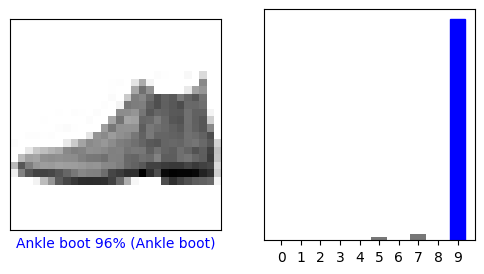


Plotting training history...


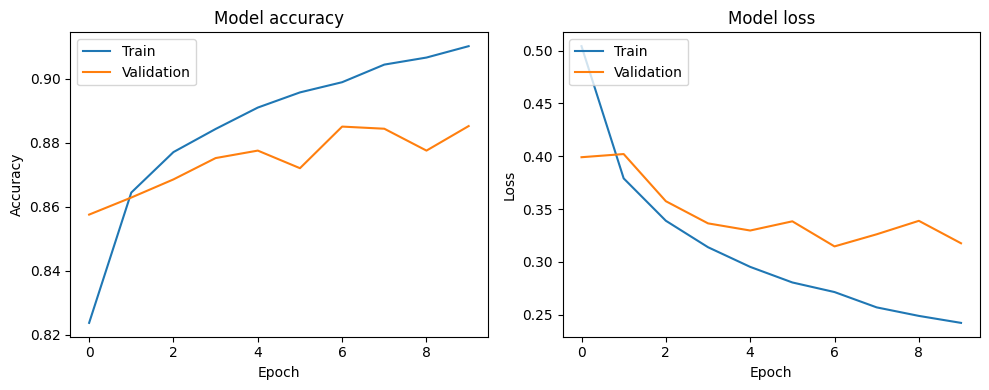

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Define data location
DATA_PATH = 'data' # <-- EDIT THIS PATH

##BASElINE MODEL - no modifications for comparison
# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels



try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()


# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Preprocess the Data, normilize pixel data from 0~200 to 0~1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

# Step 3: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 4: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

# Step 5: Train the Model
print("\nStarting model training...")
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.1)
print("Model training finished.")

# Step 6: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 7: Make Predictions
predictions = model.predict(test_images)

# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()



Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)


Starting model training...
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 102s 116ms/step - accuracy: 0.7908 - loss: 0.6316 - val_accuracy: 0.8878 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 145s 120ms/step - accuracy: 0.8910 - loss: 0.3030 - val_accuracy: 0.9022 - val_loss: 0.2628 - learning_rate: 0.0010
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9070 - loss: 0.2515
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 100s 118ms/step - accuracy: 0.9070 - loss: 0.2515 - val_accuracy: 0.8983 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 112s 133ms/step - accuracy: 0.9258 - loss: 0.1988 - val_accuracy: 0.9225 - val_loss: 0.2099 - learning_rate: 5.0000e-04
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9350 - loss: 0.1697
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
844/844 ━━━━━━━━━━━━━━━━━━━

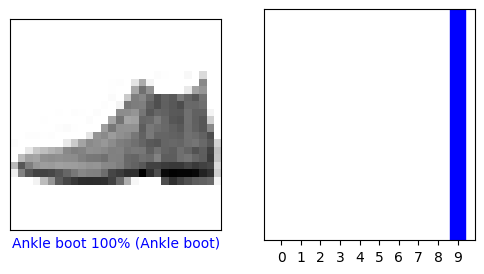

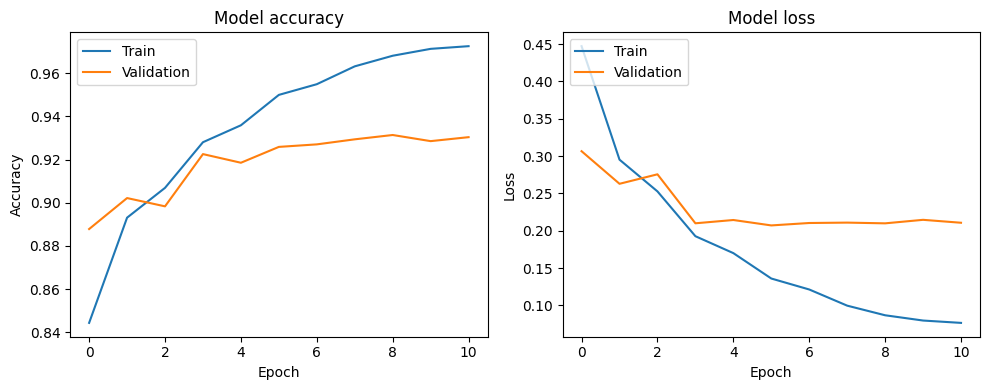

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

##MODEL WITH CNN IMPLEMENTATION
# Define data location
DATA_PATH = 'data'  # <-- EDIT THIS IF NEEDED

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels


# Load data
try:
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Normalize images
train_images = train_images / 255.0
test_images = test_images / 255.0

# Step 3: CNN Model, Batch Normalization for more stable training. MaxPooling for reducing computation, Dropout to reduce overfitting, Reshape  CNN requires height×width×channels.

model = tf.keras.Sequential([
    # Add channel dimension so CNN can process the image
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 4: Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Summary:")
model.summary()

#Step 5: Callbacks to train the model faster. EarlyStop to stop training when improvement is no longer seen, reduceLRonPlateau to automatically slow down the learning rate when the model gets stuck
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=1,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(
    train_images, train_labels,
    epochs=15,               # increase epoch from 10 to 15
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)
print("Model training finished.")


# Step 7: Evaluate Model
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')


# Step 8: Make Predictions
predictions = model.predict(test_images)

# Helper functions for visualization
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% "
               f"({class_names[true_label]})", color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Visualize prediction for the first test image
print("\nVisualizing prediction for the first test image...")
i = 0
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions[i], test_labels)
plt.show()


# Step 9: Plot Training History
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()